In [1]:
# import the libraries\
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
%matplotlib inline

In [3]:
# get the dataset
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Historical_Wildfires.csv"
df_fire = pd.read_csv(URL)
df_fire.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R


In [5]:
# column names in daraframe
df_fire.columns

Index(['Region', 'Date', 'Estimated_fire_area',
       'Mean_estimated_fire_brightness', 'Mean_estimated_fire_radiative_power',
       'Mean_confidence', 'Std_confidence', 'Var_confidence', 'Count',
       'Replaced'],
      dtype='object')

In [8]:
# types of data
df_fire.dtypes

Region                                  object
Date                                    object
Estimated_fire_area                    float64
Mean_estimated_fire_brightness         float64
Mean_estimated_fire_radiative_power    float64
Mean_confidence                        float64
Std_confidence                         float64
Var_confidence                         float64
Count                                    int64
Replaced                                object
dtype: object

In [10]:
# add Month and Year columns to the dataframe
import datetime as dt
Year = pd.to_datetime(df_fire['Date']).dt.year
Month = pd.to_datetime(df_fire['Date']).dt.month

In [11]:
# add to dataframe
df_fire['Year']=Year
df_fire['Month']=Month

In [12]:
df_fire.head()

,Region,Date,Estimated_fire_area,Mean_estimated_fire_brightness,Mean_estimated_fire_radiative_power,Mean_confidence,Std_confidence,Var_confidence,Count,Replaced,Year,Month
0,NSW,1/4/2005,8.68000,312.266667,42.400000,78.666667,2.886751,8.333333,3,R,2005,1
1,NSW,1/5/2005,16.61125,322.475000,62.362500,85.500000,8.088793,65.428571,8,R,2005,1
2,NSW,1/6/2005,5.52000,325.266667,38.400000,78.333333,3.214550,10.333333,3,R,2005,1
3,NSW,1/7/2005,6.26400,313.870000,33.800000,92.200000,7.529940,56.700000,5,R,2005,1
4,NSW,1/8/2005,5.40000,337.383333,122.533333,91.000000,7.937254,63.000000,3,R,2005,1


## Task 1.1 Change in estimated fire area over time
Visually represent how much avg area each year was burned

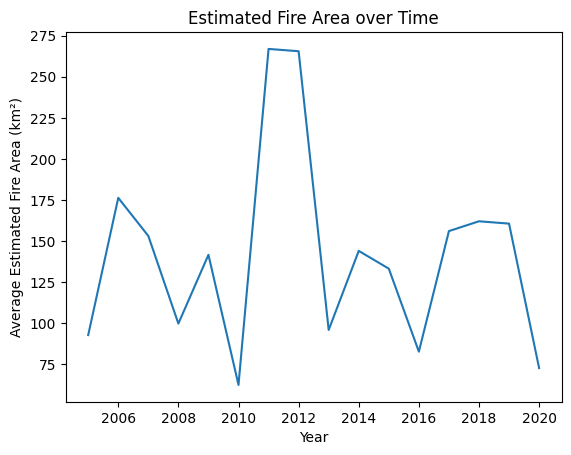

In [14]:
avg_area = df_fire.groupby('Year')['Estimated_fire_area'].mean()

#Use pandas to plot
plt.Figure(figsize=(10,6))

avg_area.plot(x=avg_area.index, y=avg_area.values)
plt.xlabel('Year')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

There is a peak from 2010 to 2013. need a more detailed view

## Task 1.2 Plot estimated fire area grouped by Year and Month

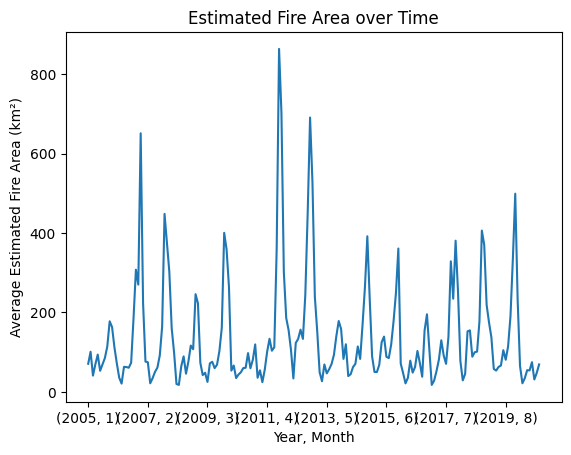

In [16]:
# group the areas according to month and year
avg_m = df_fire.groupby(['Year','Month'])['Estimated_fire_area'].mean()

avg_m.plot(x=avg_m.index, y=avg_m.values)
plt.xlabel('Year, Month')
plt.ylabel('Average Estimated Fire Area (km²)')
plt.title('Estimated Fire Area over Time')
plt.show()

This plot represents that the estimated fire area was on its peak after 2011, April and before 2012. You can verify on google/news, this was the time of maximum wildfire hit in Austrailia

## Task 1.3 Distribution of mean estimated fire brightness across the regions using barplots from seaborn

In [18]:
# lets find out how many regions is the data divided into
df_fire['Region'].unique()

array(['NSW', 'NT', 'QL', 'SA', 'TA', 'VI', 'WA'], dtype=object)

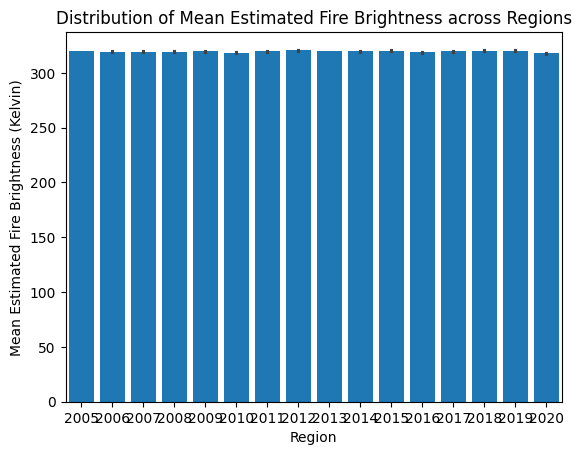

In [23]:
plt.Figure(figsize=(10,6))
sns.barplot(data=df_fire, x='Year', y='Mean_estimated_fire_brightness', saturation=1)
plt.xlabel('Region')
plt.ylabel('Mean Estimated Fire Brightness (Kelvin)')
plt.title('Distribution of Mean Estimated Fire Brightness across Regions')
plt.show()

## Task 1.4 Pie plot to show portion of count of pixels for presumed vegetation fires across different region

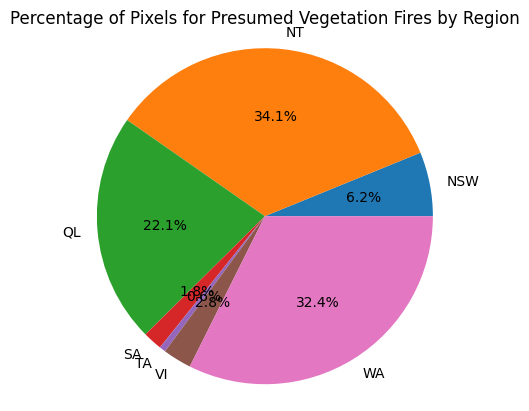

In [25]:
# group the data by regions and summ the counts
regs = df_fire.groupby('Region')['Count'].sum()

# plot
plt.Figure(figsize=(10,6))
plt.pie(regs, labels=regs.index, autopct='%1.1f%%')
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.axis('equal')
plt.show()

## Task 1.5 Correct the percentages in figure

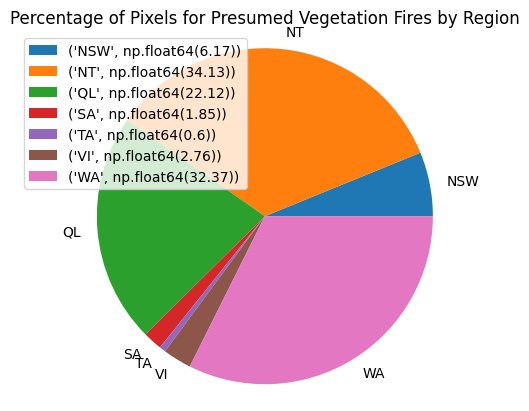

In [26]:
plt.Figure(figsize=(10,6))
plt.pie(regs, labels=regs.index)
plt.title('Percentage of Pixels for Presumed Vegetation Fires by Region')
plt.legend([(i,round(k/regs.sum()*100,2)) for i,k in zip(regs.index, regs)])
plt.axis('equal')
plt.show()

## Task 1.6 Histogram of the mean estimated fire brightness

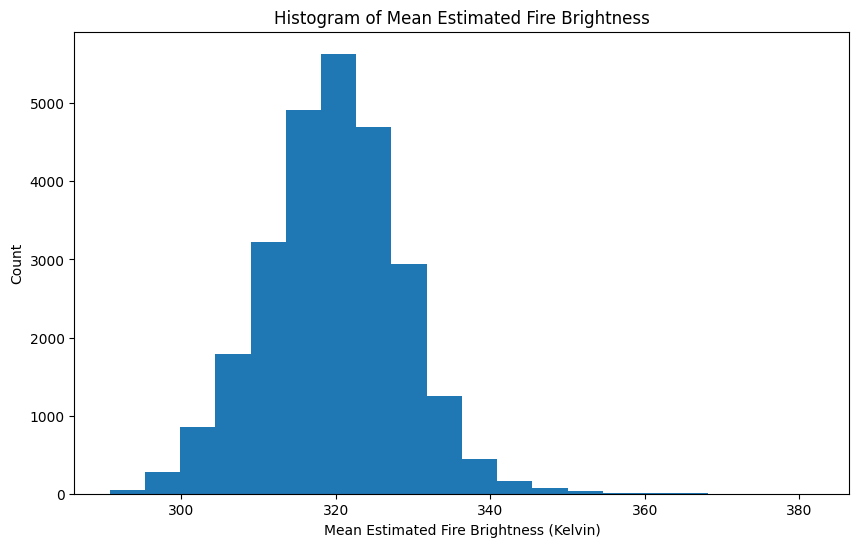

In [28]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness
plt.figure(figsize=(10, 6))
# Using plt.hist to create the histogram
# Setting the number of bins to 20 for better visualization
plt.hist(x=df_fire['Mean_estimated_fire_brightness'], bins=20)
plt.xlabel('Mean Estimated Fire Brightness (Kelvin)')
plt.ylabel('Count')
plt.title('Histogram of Mean Estimated Fire Brightness')
plt.show()

## Task 1.7 The distribution of estimated fire brightness across regions?
use the functionality of seaborn and  pass region as hue

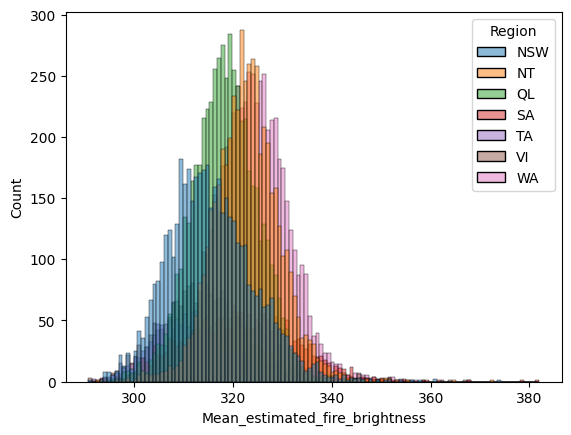

In [29]:
# Creating a histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the histogram
# Specifying the DataFrame (data=df) and the column for the x-axis (x='Mean_estimated_fire_brightness')
# Adding hue='Region' to differentiate the distribution across regions
sns.histplot(data=df_fire, x='Mean_estimated_fire_brightness', hue='Region')
plt.show()

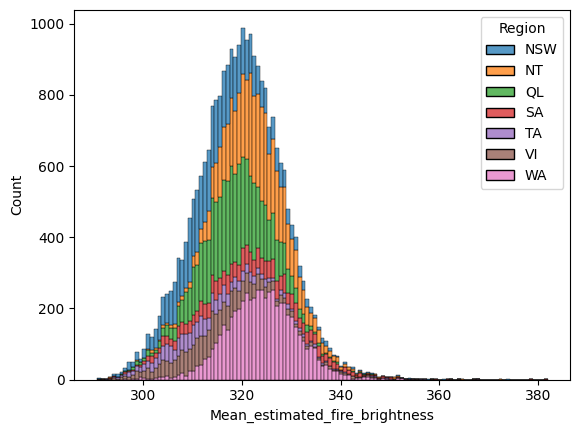

In [30]:
# Creating a stacked histogram to visualize the distribution of mean estimated fire brightness across regions using Seaborn
# Using sns.histplot to create the stacked histogram
# Specifying the DataFrame (data=df) and the column for the x-axis (x='Mean_estimated_fire_brightness')
# Adding hue='Region' to differentiate the distribution across regions
# Setting multiple='stack' to stack the histograms for different regions
sns.histplot(data=df_fire, x='Mean_estimated_fire_brightness', hue='Region', multiple='stack')
plt.show()

## Task 1.8 Find correlation between est. fire radiative power and mean confidence level

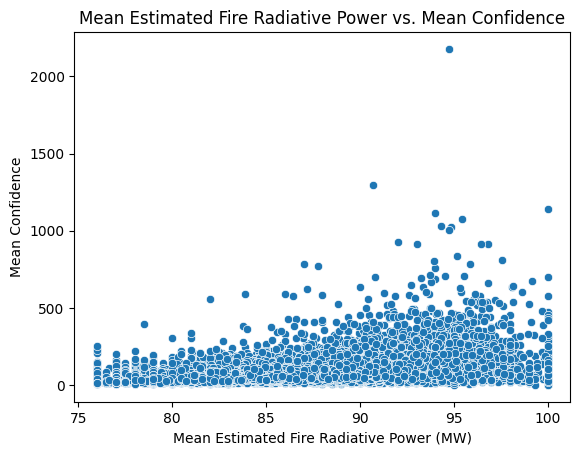

In [32]:
plt.Figure(figsize=(10,8))
sns.scatterplot(data=df_fire, x='Mean_confidence', y='Mean_estimated_fire_radiative_power')
plt.xlabel('Mean Estimated Fire Radiative Power (MW)')
plt.ylabel('Mean Confidence')
plt.title('Mean Estimated Fire Radiative Power vs. Mean Confidence')
plt.show()

## Task 1.9 Mark the regions in the Map using Folium

In [33]:
region_data = {'region':['NSW','QL','SA','TA','VI','WA','NT'], 'Lat':[-31.8759835,-22.1646782,-30.5343665,-42.035067,-36.5986096,-25.2303005,-19.491411], 
               'Lon':[147.2869493,144.5844903,135.6301212,146.6366887,144.6780052,121.0187246,132.550964]}
reg=pd.DataFrame(region_data)
reg

,region,Lat,Lon
0,NSW,-31.875984,147.286949
1,QL,-22.164678,144.584490
2,SA,-30.534367,135.630121
3,TA,-42.035067,146.636689
4,VI,-36.598610,144.678005
5,WA,-25.230300,121.018725
6,NT,-19.491411,132.550964


In [35]:
# create a feture group
aus_reg = folium.map.FeatureGroup()
australia = folium.Map(location=[-25, 135], zoom_start=4)

# use a loop to add the regions above
for lat, lng, lab in zip(reg.Lat, reg.Lon, reg.region):
    aus_reg.add_child(
        folium.features.CircleMarker(
            [lat, lng],
            popup=lab,
            radius=5, # define how big you want the circle markers to be
            color='red',
            fill=True,
            fill_color='blue',
            fill_opacity=0.6
        )
    )

# add incidents to map
australia.add_child(aus_reg)